# 04 Unsupervised Clustering Analysis

This notebook focuses on discovering latent population structures using unsupervised clustering.
We construct a compact, interpretable feature space, apply multiple clustering algorithms,
evaluate clustering quality, and interpret the resulting clusters using both selected and
non-selected features.


## 1. load library and data

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

In [5]:
df = pd.read_csv("../data/diabetes_processed.csv")
df.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,target
0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0,0
1,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0,0
2,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0,0
3,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0,0
4,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0,0


In [6]:
df["Diet_Score"] = df["Fruits"] + df["Veggies"]

scaler = StandardScaler()
df[["Income_z", "Education_z"]] = scaler.fit_transform(
    df[["Income", "Education"]]
)

df["SES_Score"] = df["Income_z"] + df["Education_z"]

cluster_features = [
    "BMI",
    "Diet_Score",
    "SES_Score",
    "PhysActivity",
    "Age",
    "Smoker"
]

X_cluster = df[cluster_features]
X_cluster.head()


,BMI,Diet_Score,SES_Score,PhysActivity,Age,Smoker
0,40.0,1.0,-2.540082,0.0,9.0,1.0
1,25.0,0.0,-1.476866,1.0,7.0,1.0
2,28.0,1.0,-0.125957,0.0,9.0,0.0
3,27.0,2.0,-2.106040,1.0,11.0,0.0
4,24.0,2.0,-1.042824,1.0,11.0,0.0


In [7]:
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

In [8]:
from sklearn.preprocessing import QuantileTransformer

qt = QuantileTransformer(
    output_distribution="normal",
    n_quantiles=min(1000, len(X_cluster)),
    random_state=42
)

X_cluster_gaussian = qt.fit_transform(X_cluster)

X_cluster_gaussian = pd.DataFrame(
    X_cluster_gaussian,
    columns=X_cluster.columns,
    index=X_cluster.index
)

X_cluster_gaussian.head()


,BMI,Diet_Score,SES_Score,PhysActivity,Age,Smoker
0,1.639539,-0.593940,-1.331018,-5.199338,0.218773,5.199338
1,-0.497809,-5.199338,-0.774833,5.199338,-0.393847,5.199338
2,0.144780,-0.593940,-0.258792,-5.199338,0.218773,-5.199338
3,-0.058999,5.199338,-1.194628,5.199338,0.928105,-5.199338
4,-0.718462,5.199338,-0.589456,5.199338,0.928105,-5.199338


<Axes: >

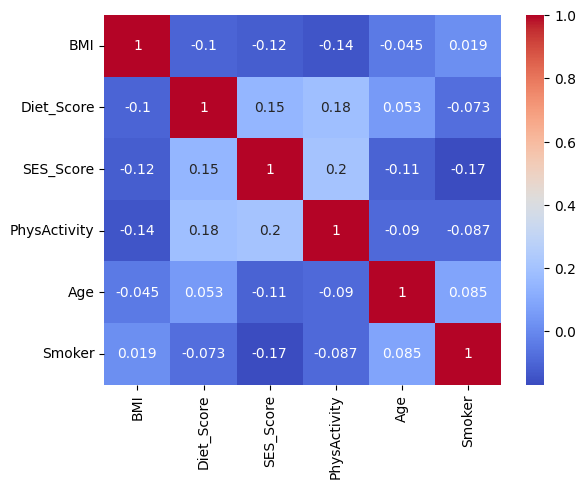

In [9]:
sns.heatmap(
    X_cluster_gaussian.corr(),
    annot=True, cmap="coolwarm"
)


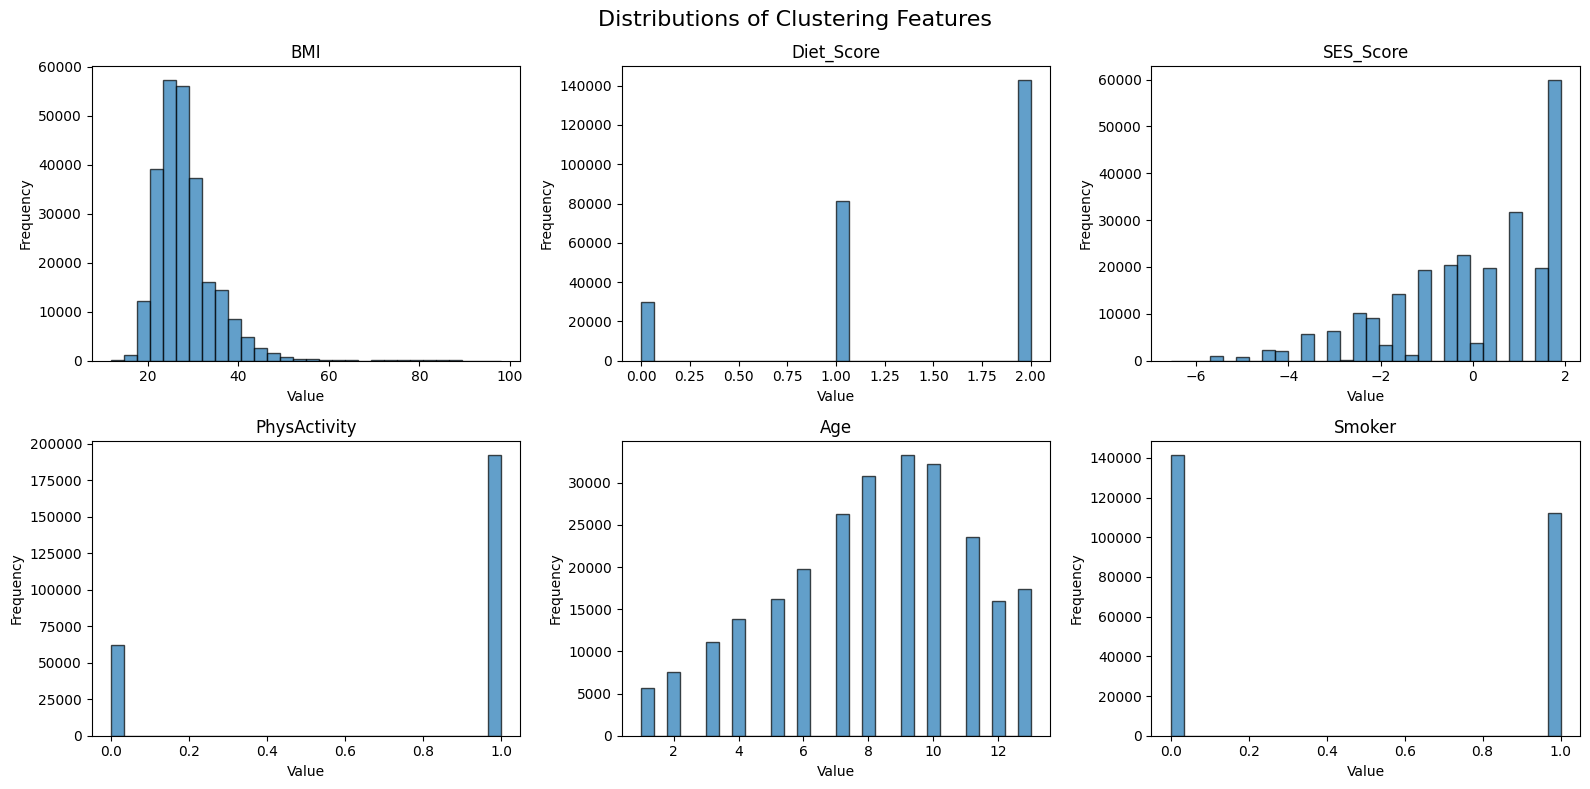

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, feature in zip(axes, cluster_features):
    ax.hist(
        X_cluster[feature],
        bins=30,
        edgecolor="black",
        alpha=0.7
    )
    ax.set_title(feature)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.suptitle("Distributions of Clustering Features", fontsize=16)
plt.tight_layout()
plt.show()

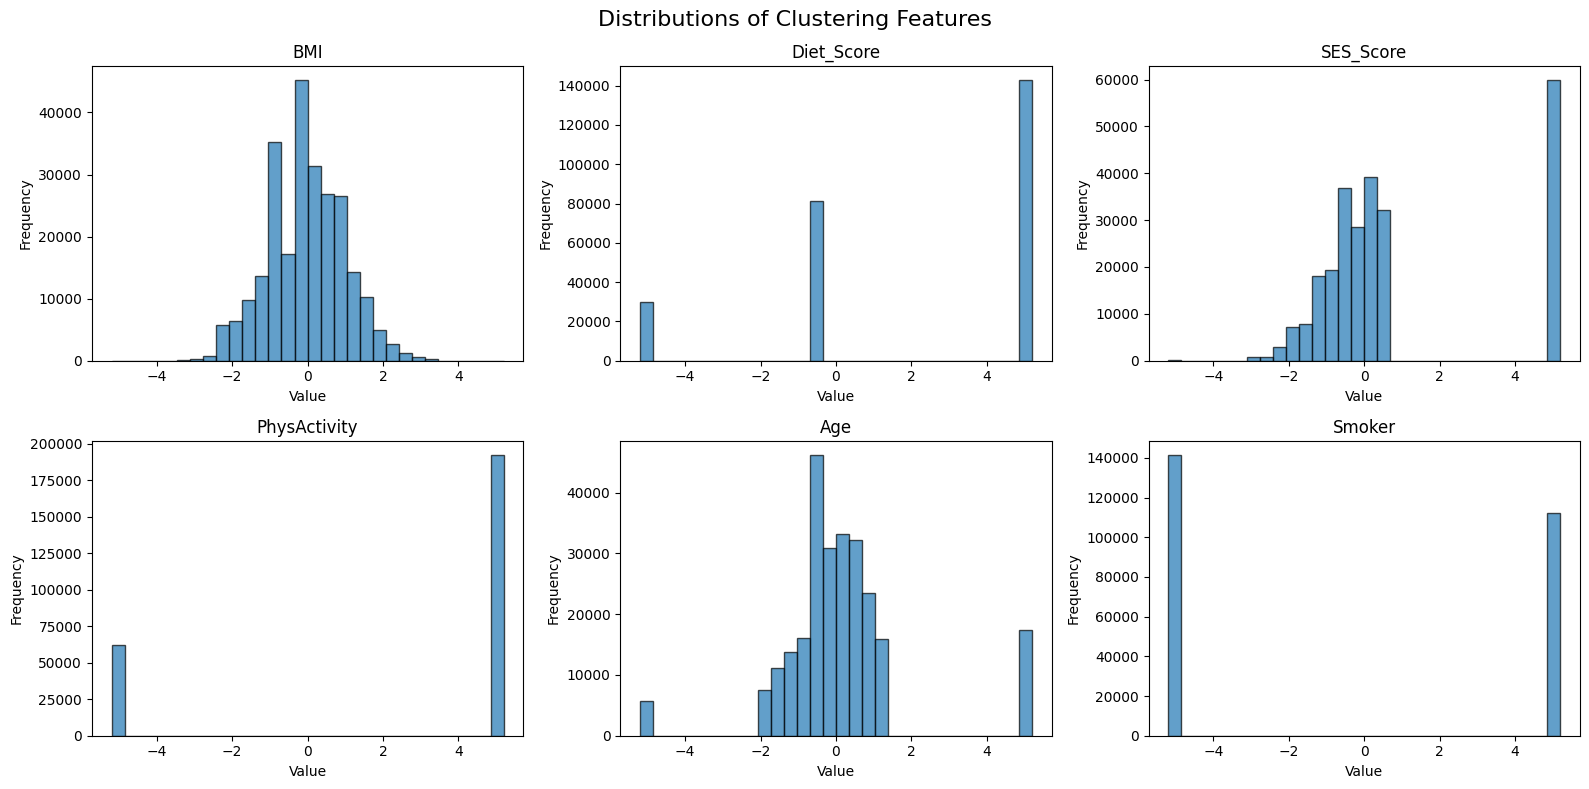

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, feature in zip(axes, cluster_features):
    ax.hist(
        X_cluster_gaussian[feature],
        bins=30,
        edgecolor="black",
        alpha=0.7
    )
    ax.set_title(feature)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.suptitle("Distributions of Clustering Features", fontsize=16)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'PCA projection of clustering features')

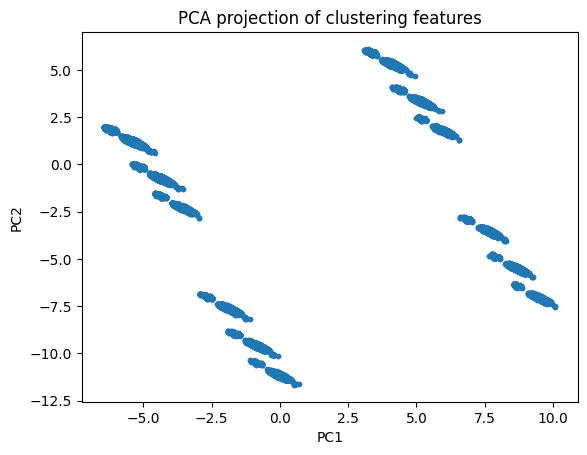

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_gaussian)

plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of clustering features")


Text(0.5, 1.0, 'PCA projection of clustering features')

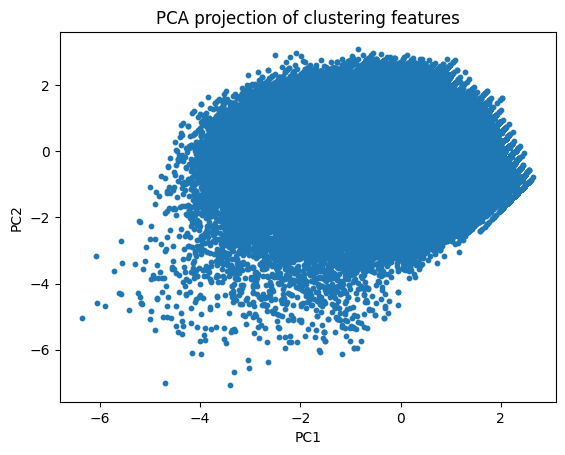

In [13]:
pca_scale = PCA(n_components=2)
X_pca_scaled = pca_scale.fit_transform(X_cluster_scaled)

plt.scatter(X_pca_scaled[:, 0], X_pca_scaled[:, 1], s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of clustering features")

## 2. K-Means

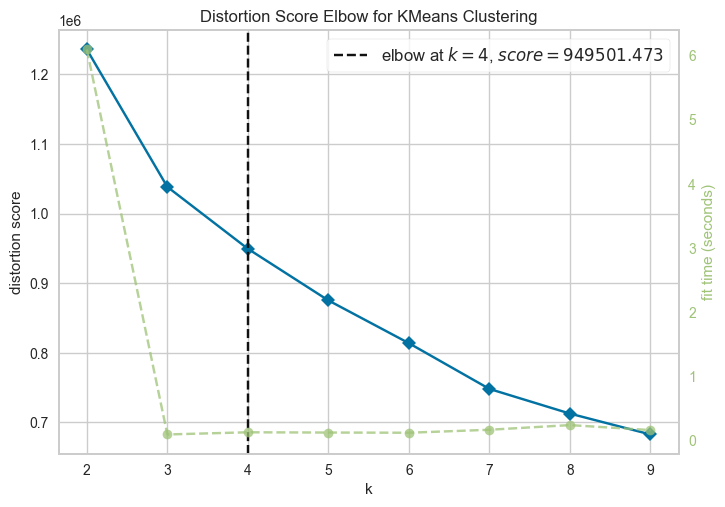

In [14]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

km = KMeans(random_state=1)
visualizer = KElbowVisualizer(km, k=(2,10), force_model=True)

visualizer.fit(X_cluster_scaled)
visualizer.show()
plt.show()

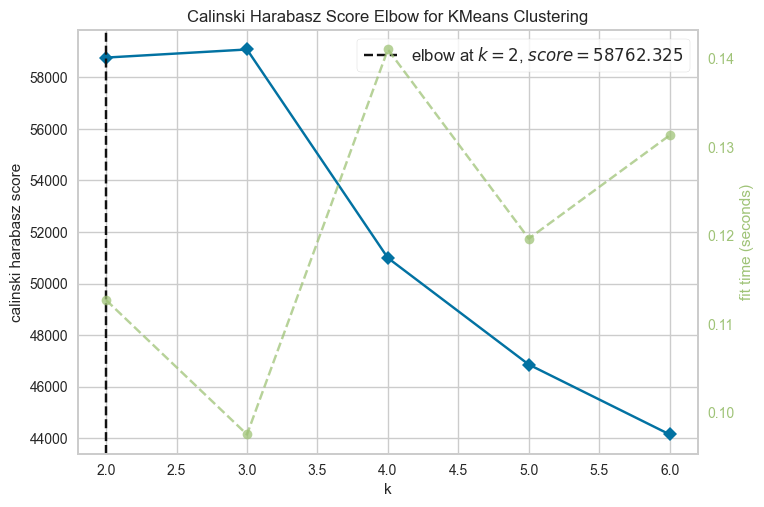

In [15]:
km= KMeans(random_state=1)
visualizer = KElbowVisualizer(km, k=(2,7), metric='calinski_harabasz', force_model=True)

visualizer.fit(X_cluster_scaled)
visualizer.show()
plt.show()

In [16]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels_km = kmeans.fit_predict(X_cluster_scaled)


from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
ch_score = calinski_harabasz_score(X_cluster_scaled, labels_km)
print('calinski_harabasz_score:', ch_score)

db_score = davies_bouldin_score(X_cluster_scaled, labels_km)
print('davies_bouldin_score:', db_score)

calinski_harabasz_score: 59076.53783289013
davies_bouldin_score: 1.6644133971371111


Text(0.5, 1.0, 'K-Means clusters (PCA space)')

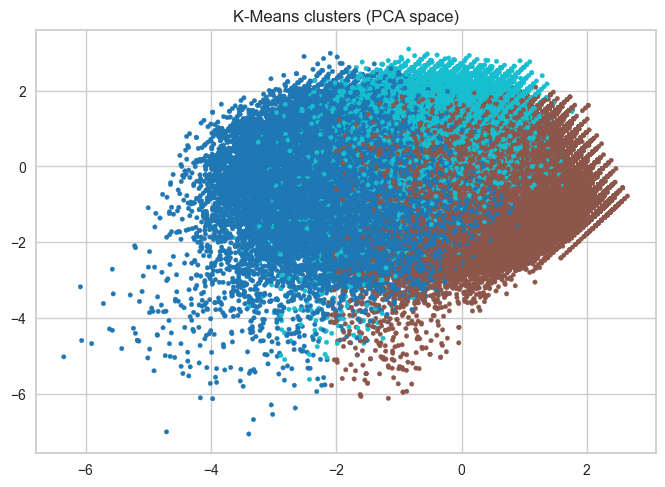

In [17]:
plt.scatter(X_pca_scaled[:, 0], X_pca_scaled[:, 1], c=labels_km, cmap="tab10", s=10)
plt.title("K-Means clusters (PCA space)")

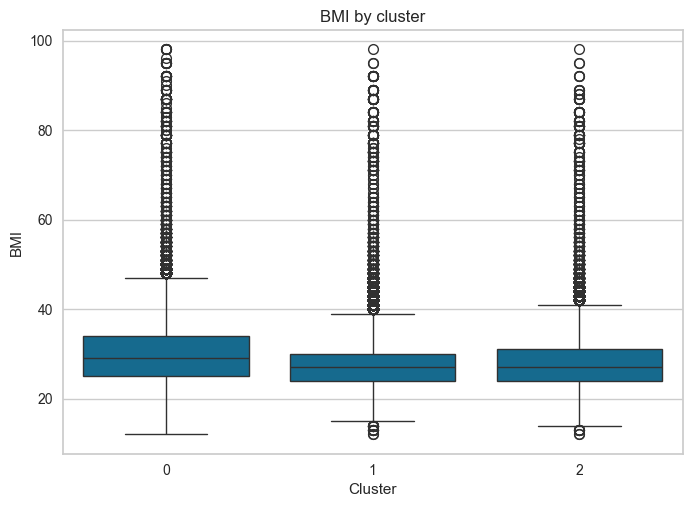

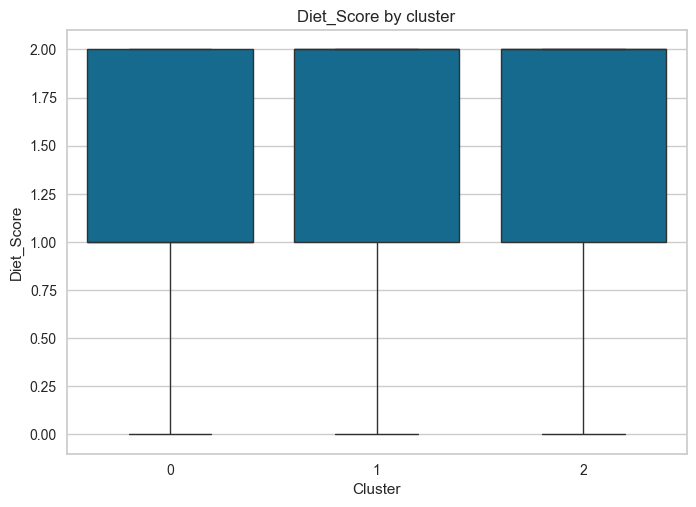

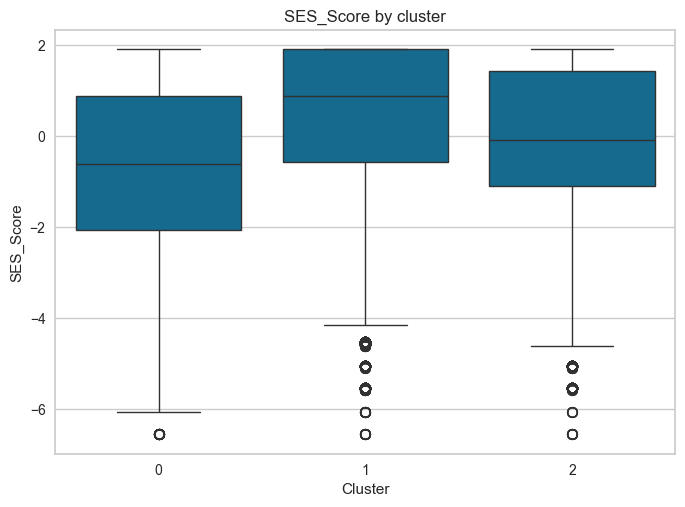

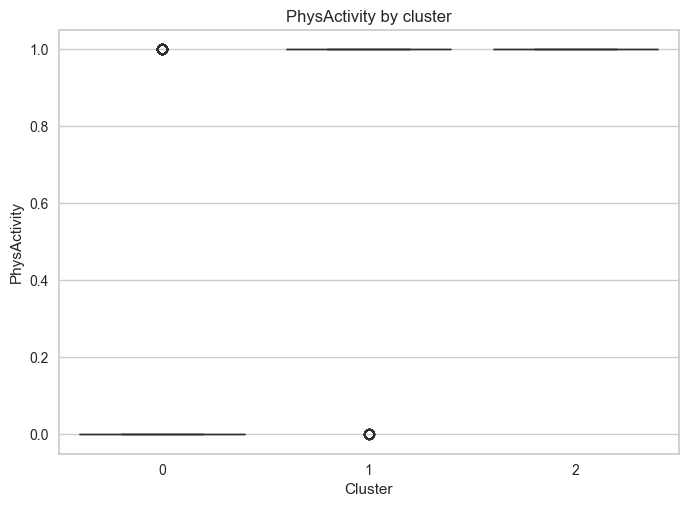

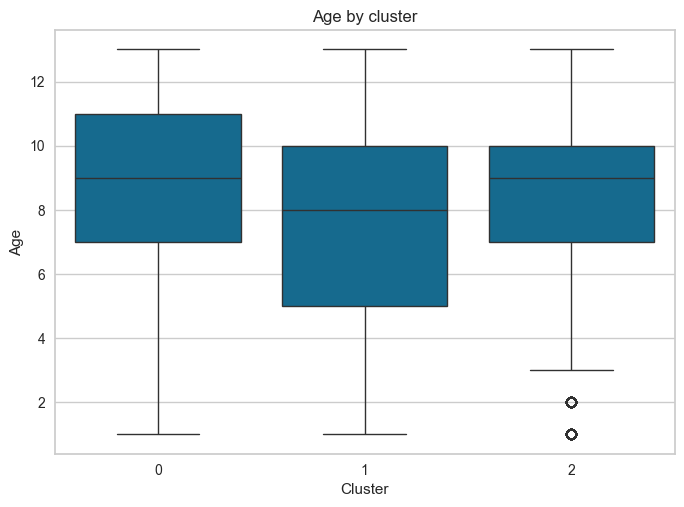

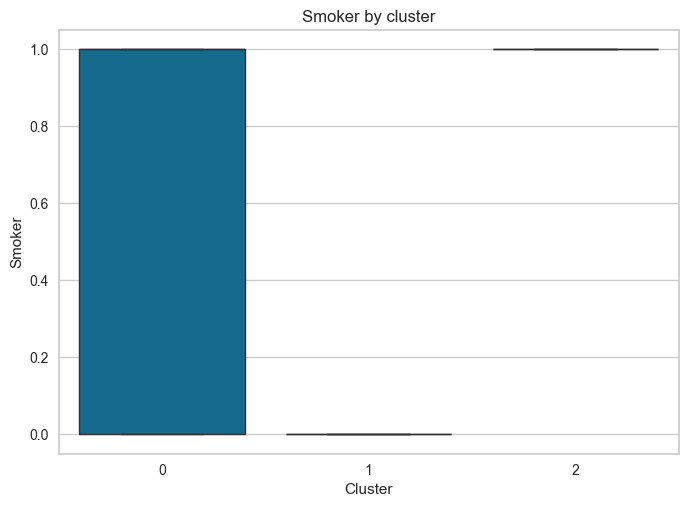

In [18]:
df["Cluster"] = labels_km

for col in cluster_features:
    sns.boxplot(x="Cluster", y=col, data=df)
    plt.title(f"{col} by cluster")
    plt.show()

## 3. GMM

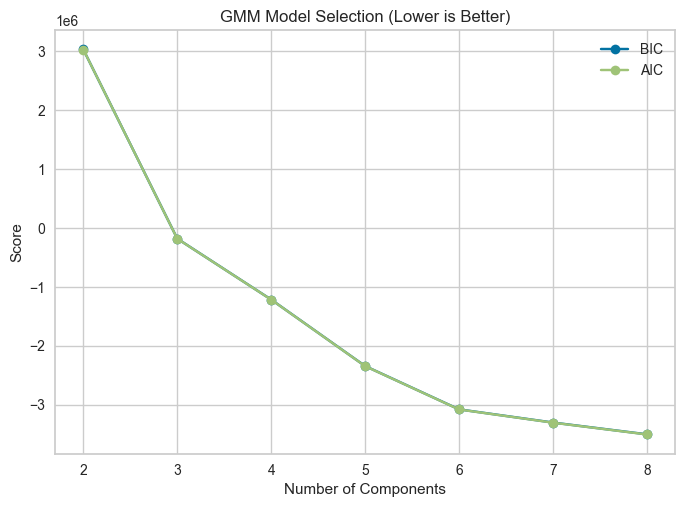

In [19]:
from sklearn.mixture import GaussianMixture

bic_scores = []
aic_scores = []
K_range = range(2, 9)

for k in K_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42
    )
    gmm.fit(X_cluster_gaussian)
    bic_scores.append(gmm.bic(X_cluster_gaussian))
    aic_scores.append(gmm.aic(X_cluster_gaussian))

plt.figure()
plt.plot(K_range, bic_scores, marker='o', label='BIC')
plt.plot(K_range, aic_scores, marker='o', label='AIC')
plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.legend()
plt.title("GMM Model Selection (Lower is Better)")
plt.show()

In [20]:
best_k = 4
gmm = GaussianMixture(
    n_components=best_k,
    covariance_type='full',
    random_state=42
)

labels_gmm = gmm.fit_predict(X_cluster_gaussian)
prob_matrix = gmm.predict_proba(X_cluster_gaussian)


# Average silhouette score (optional)
from sklearn.metrics import calinski_harabasz_score
print('calinski_harabasz_score:', calinski_harabasz_score(X_cluster_gaussian, labels_gmm))
from sklearn.metrics import davies_bouldin_score
print('davies_bouldin_score:', davies_bouldin_score(X_cluster_gaussian, labels_gmm))

calinski_harabasz_score: 174135.8939433536
davies_bouldin_score: 0.8729750085367798


Text(0.5, 1.0, 'K-Means clusters (PCA space)')

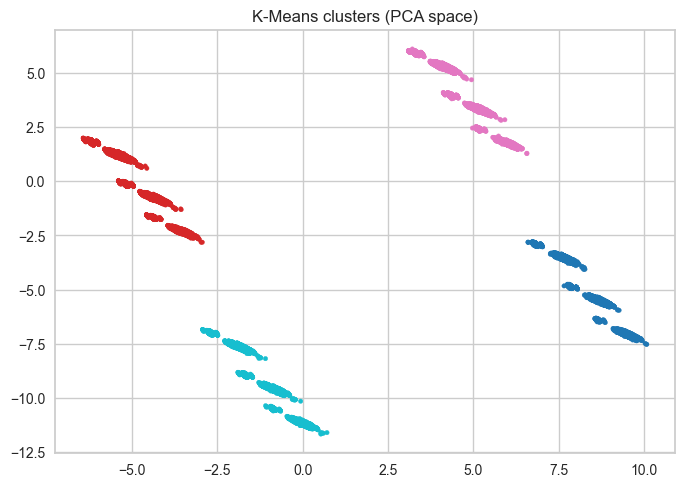

In [21]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_gmm, cmap="tab10", s=10)
plt.title("K-Means clusters (PCA space)")

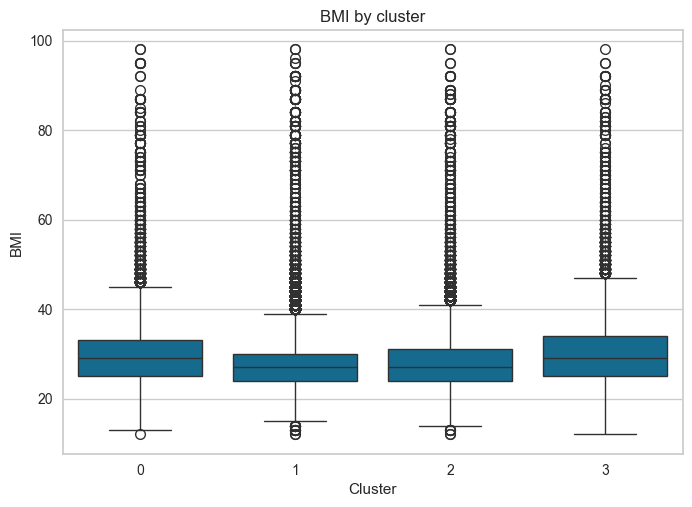

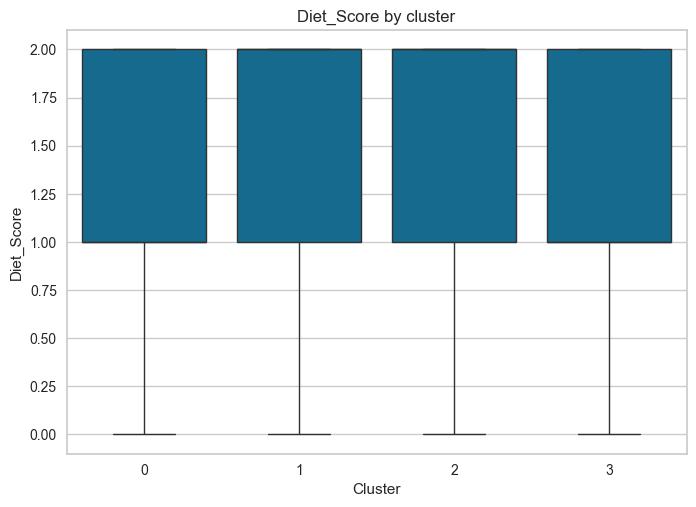

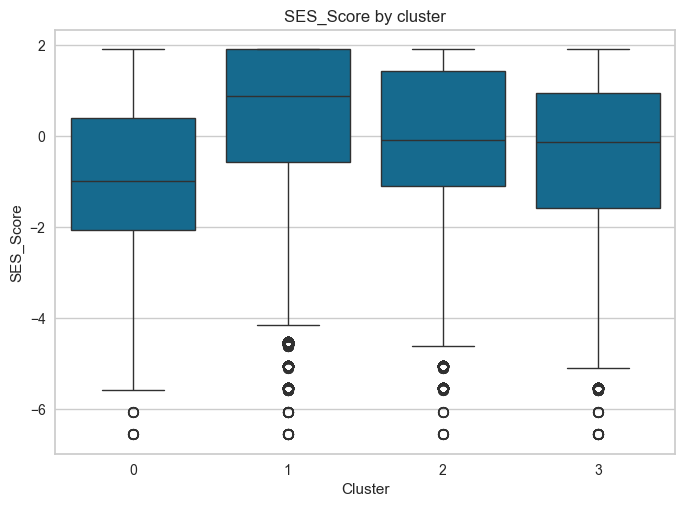

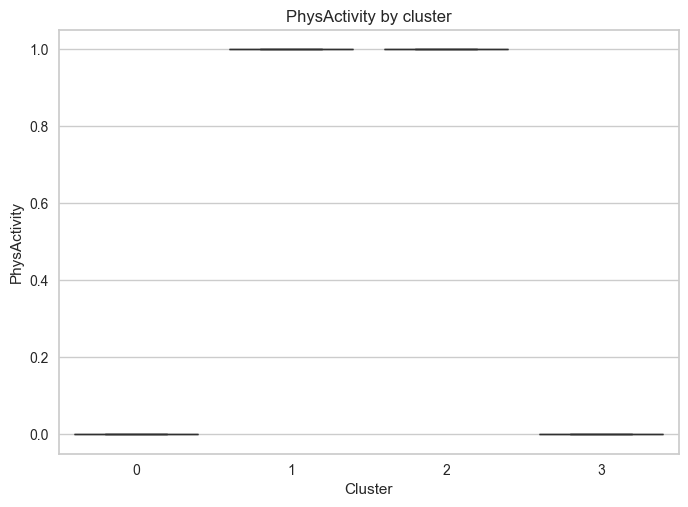

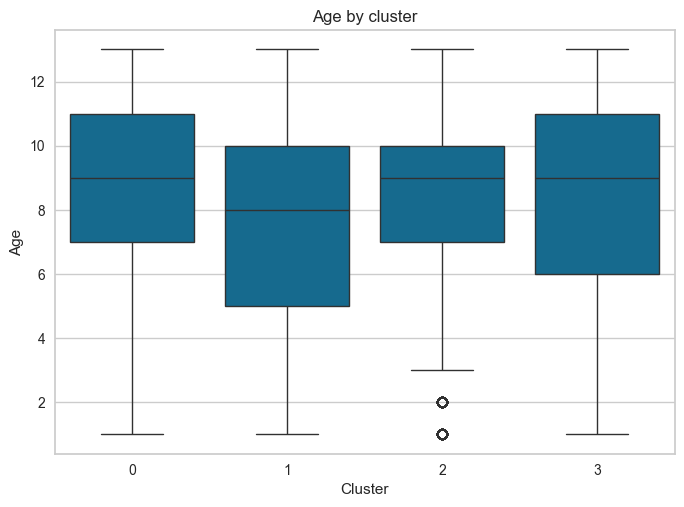

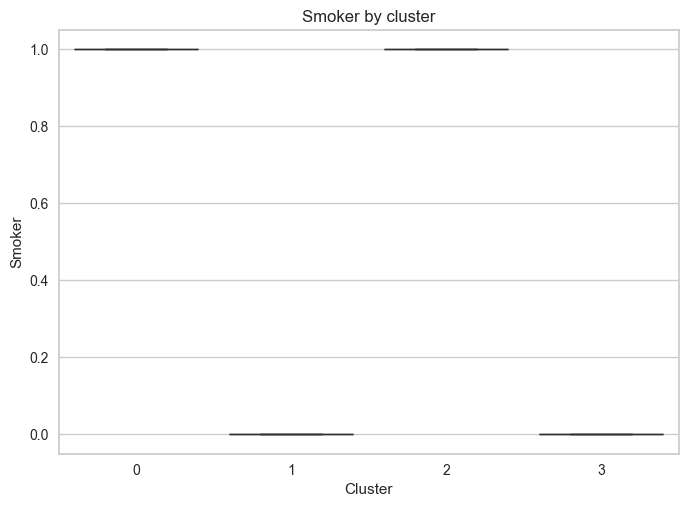

In [22]:
df["Cluster"] = labels_gmm

for col in cluster_features:
    sns.boxplot(x="Cluster", y=col, data=df)
    plt.title(f"{col} by cluster")
    plt.show()

## 4. 层次聚类

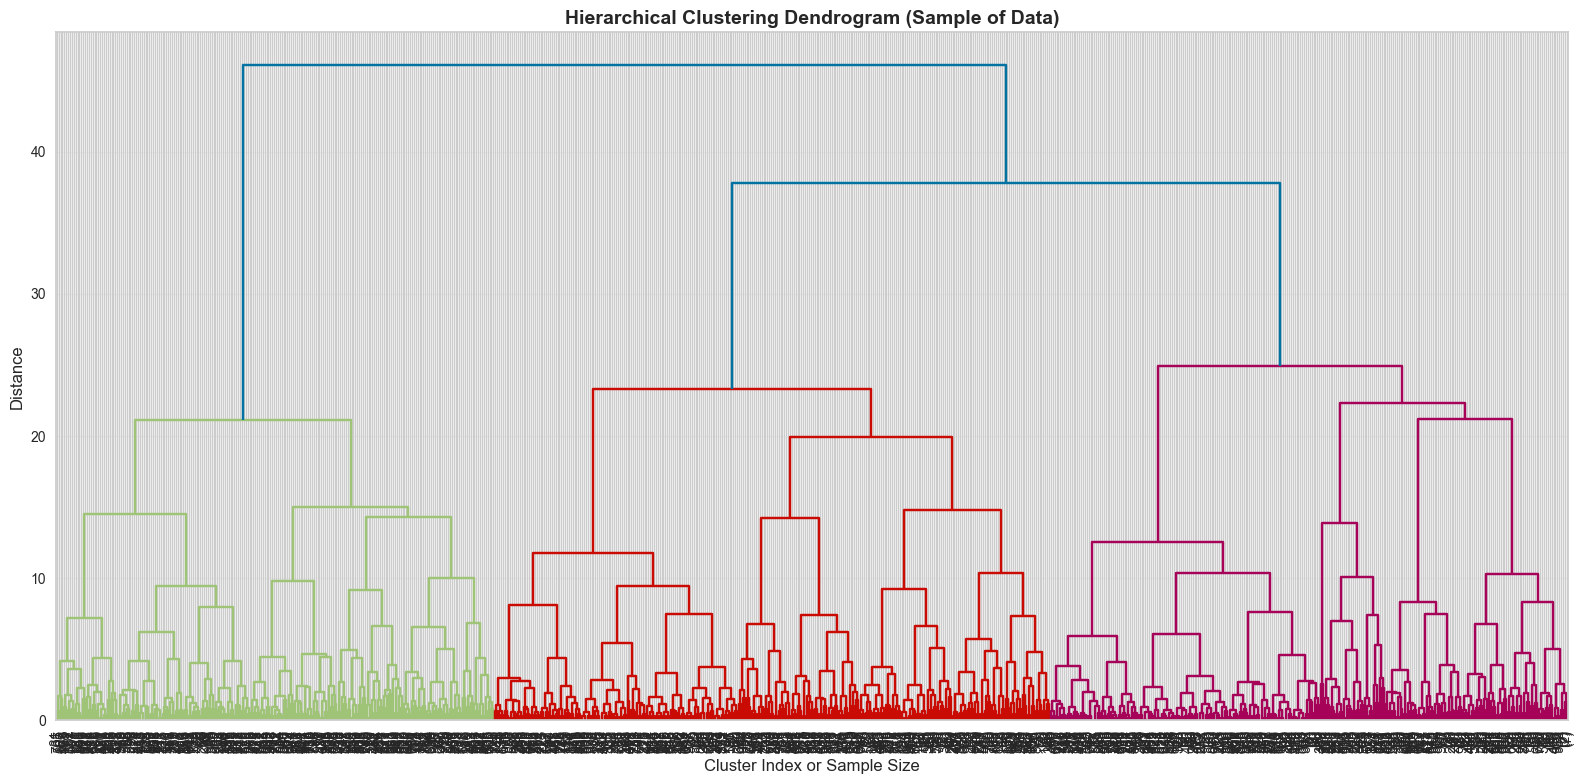

In [23]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# ================================
# 1. 层次聚类：构建层次树（抽样避免内存溢出）
# ================================

# Sample the data to avoid memory overflow (linkage is O(n^2))
sample_size = min(1000, len(X_cluster_scaled))
indices = np.random.choice(len(X_cluster_scaled), size=sample_size, replace=False)
X_sample_hc = X_cluster_scaled[indices]

Z = linkage(X_sample_hc, method='ward')  # ward 方法 + 欧式距离

# ================================
# 2. 画树状图 (Dendrogram)
# ================================

plt.figure(figsize=(16, 8))
dendrogram(Z, truncate_mode='level', p=10, leaf_rotation=90, leaf_font_size=10)
plt.title("Hierarchical Clustering Dendrogram (Sample of Data)", fontsize=14, fontweight='bold')
plt.xlabel("Cluster Index or Sample Size", fontsize=12)
plt.ylabel("Distance", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Explaination

In [24]:
df["Cluster"] = labels_gmm

# Group by cluster to observe differences
numeric_cols = df.select_dtypes(include='number').columns
summary = df.groupby('Cluster')[numeric_cols].mean()
summary

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,Sex,Age,Education,Income,target,Diet_Score,Income_z,Education_z,SES_Score,Cluster
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.561984,0.524005,0.957940,29.781942,1.0,0.077795,0.174160,0.0,0.478892,0.700689,...,0.464156,8.734181,4.581737,5.153597,0.246783,1.179581,-0.434677,-0.475462,-0.910139,0.0
1,0.352555,0.364267,0.964210,27.732226,0.0,0.024338,0.054564,1.0,0.698891,0.851569,...,0.410416,7.542305,5.287928,6.485976,0.114262,1.550460,0.208629,0.240922,0.449551,1.0
2,0.451174,0.454996,0.961606,27.966238,1.0,0.044631,0.114670,1.0,0.637652,0.836840,...,0.503772,8.329644,4.987252,6.010906,0.157832,1.474491,-0.020747,-0.064094,-0.084840,2.0
3,0.512659,0.457607,0.964872,30.440650,0.0,0.050366,0.101237,0.0,0.550012,0.711358,...,0.355392,8.309476,4.835216,5.518794,0.223410,1.261369,-0.258350,-0.218324,-0.476675,3.0


In [25]:
df["Cluster"].value_counts().sort_index()

Cluster
0     32097
1    111594
2     80326
3     29663
Name: count, dtype: int64

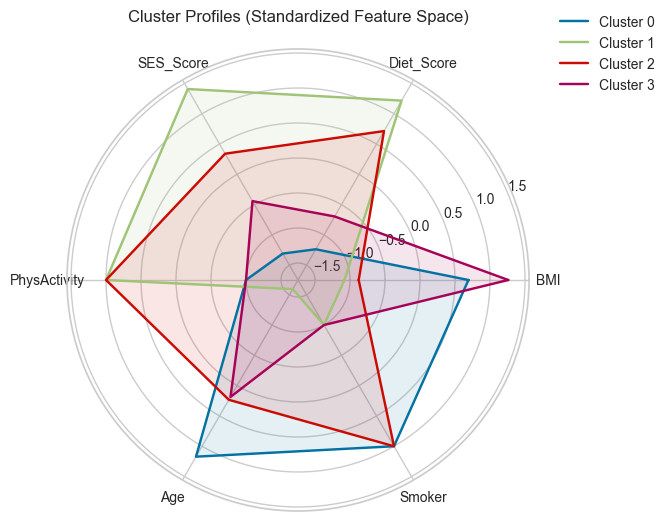

In [30]:
cluster_means = (
    df
    .groupby("Cluster")[cluster_features]
    .mean()
)

scaler = StandardScaler()
cluster_means_z = pd.DataFrame(
    scaler.fit_transform(cluster_means),
    columns=cluster_means.columns,
    index=cluster_means.index
)
labels = cluster_means_z.columns
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for cluster in cluster_means_z.index:
    values = cluster_means_z.loc[cluster].tolist()
    values += values[:1]
    
    ax.plot(angles, values, label=f"Cluster {cluster}")
    ax.fill(angles, values, alpha=0.1)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_title("Cluster Profiles (Standardized Feature Space)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.show()

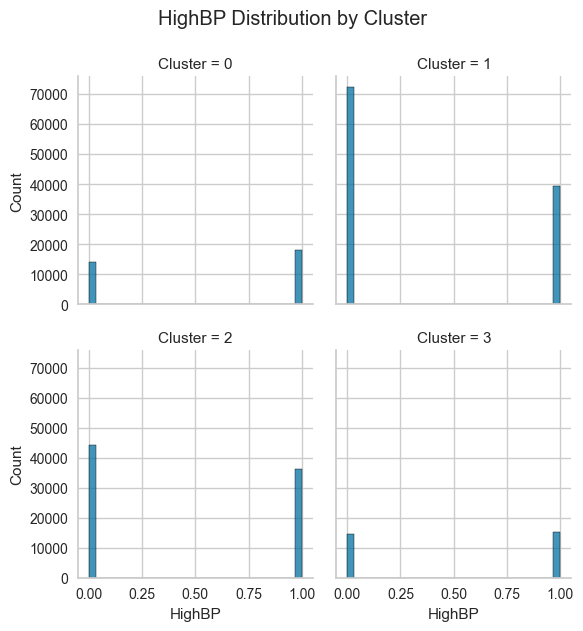

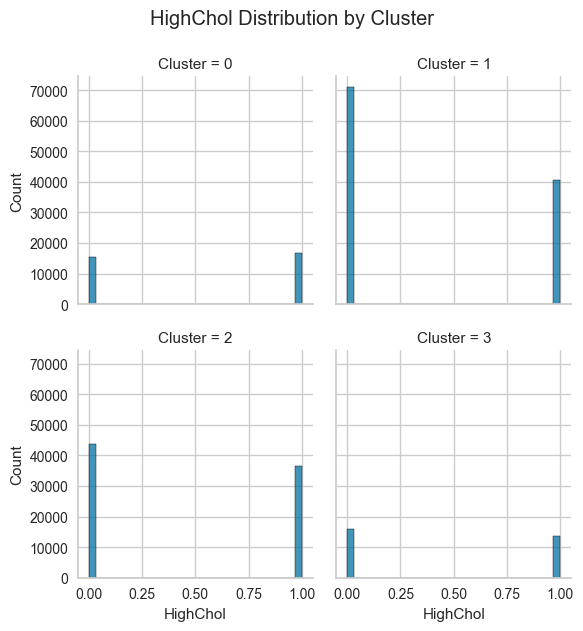

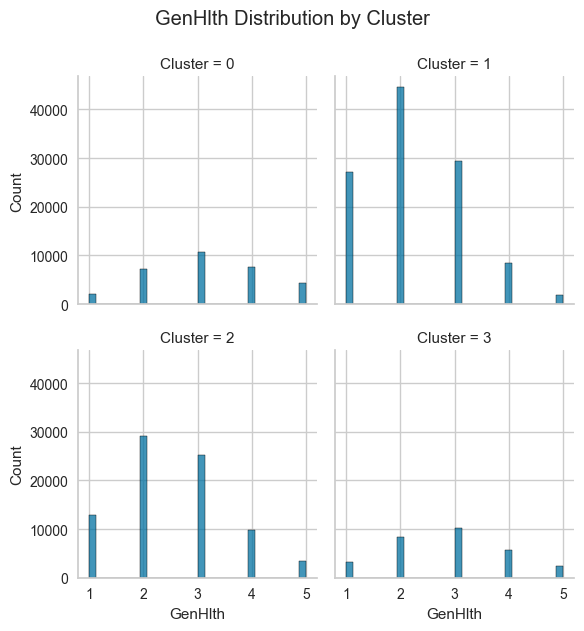

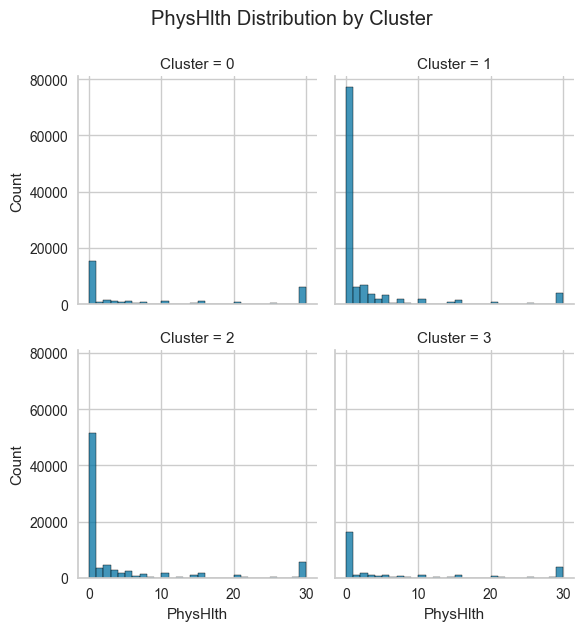

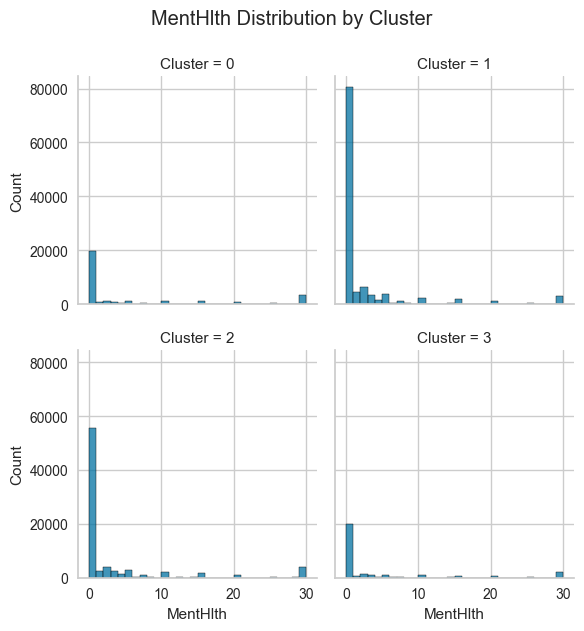

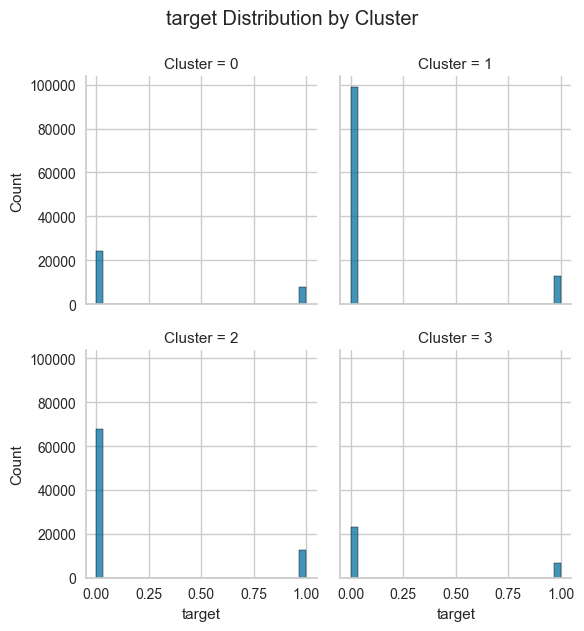

In [35]:
explain_features = [
    "HighBP",
    "HighChol",
    "GenHlth",
    "PhysHlth",
    "MentHlth",
    "target"]


for col in explain_features:
    g = sns.FacetGrid(
        df,
        col="Cluster",
        col_wrap=2,
        height=3,
        sharex=True,
        sharey=True
    )
    g.map(sns.histplot, col, bins=30)
    g.fig.suptitle(f"{col} Distribution by Cluster", y=1.05)
    plt.show()


In [36]:
summary_table = (
    df
    .groupby("Cluster")[cluster_features + explain_features]
    .mean()
    .round(2)
)

summary_table


,BMI,Diet_Score,SES_Score,PhysActivity,Age,Smoker,HighBP,HighChol,GenHlth,PhysHlth,MentHlth,target
Cluster,,,,,,,,,,,,
0,29.78,1.18,-0.91,0.0,8.73,1.0,0.56,0.52,3.16,8.82,5.65,0.25
1,27.73,1.55,0.45,1.0,7.54,0.0,0.35,0.36,2.22,2.55,2.21,0.11
2,27.97,1.47,-0.08,1.0,8.33,1.0,0.45,0.45,2.53,4.00,3.27,0.16
3,30.44,1.26,-0.48,0.0,8.31,0.0,0.51,0.46,2.85,6.30,3.94,0.22
